# Investment Value

In [1]:
# Initial imports
import os
import requests
import pandas as pd
from dotenv import load_dotenv
import alpaca_trade_api as tradeapi

%matplotlib inline

## Create a DataFrame with the current amount of shares

In [2]:
# Set current amount of shares data
shares_data = {
    "shares": [200, 320]
}

# Set the tickers
tickers = ["MSFT", "AAPL"]

# Create the shares DataFrame
df_shares = pd.DataFrame(shares_data, index=tickers)

# Display shares data
df_shares

,shares
MSFT,200
AAPL,320


## Load and Verify Environment Variables

In [3]:
# Load .env environment variables
load_dotenv()

True

In [4]:
# Set Alpaca API key and secret
alpaca_api_key = os.getenv("ALPACA_API_KEY")
alpaca_secret_key = os.getenv("ALPACA_SECRET_KEY")

In [5]:
# Verify that Alpaca key and secret were correctly loaded
print(f"Alpaca Key type: {type(alpaca_api_key)}")
print(f"Alpaca Secret Key type: {type(alpaca_secret_key)}")

Alpaca Key type: <class 'str'>
Alpaca Secret Key type: <class 'str'>


## Create the Alpaca API Object

In [6]:
# Create the Alpaca API object
alpaca = tradeapi.REST(
    alpaca_api_key,
    alpaca_secret_key,
    api_version="v2")

## Set a variable `today` with current date using ISO format

In [7]:
# Format current date as ISO format
today = pd.Timestamp("2020-07-14", tz="America/New_York").isoformat()

## Set a variable `timeframe` with value equal to `1Day`

In [8]:
# Set timeframe to one day ("1Day") for the Alpaca API
timeframe = "1Day"

## Create a DataFrame with current price data for `MSFT` & `AAPL` using `alpaca.get_bars()`

In [9]:
# Get current price data for MSFT and AAPL
df_portfolio = alpaca.get_bars(
    tickers,
    timeframe,
    start = today,
    end = today
).df

# Reorganize the DataFrame
# Separate ticker data
AAPL = df_portfolio[df_portfolio['symbol']=='AAPL'].drop('symbol', axis=1)
MSFT = df_portfolio[df_portfolio['symbol']=='MSFT'].drop('symbol', axis=1)

# Concatenate the ticker DataFrames
df_portfolio = pd.concat([AAPL, MSFT],axis=1, keys=['AAPL','MSFT'])

# Display sample data
df_portfolio

AAPL                                    \
                             open    high     low   close    volume   
timestamp                                                             
2020-07-14 04:00:00+00:00  379.36  389.02  375.51  388.23  42751670   

                                                     MSFT                  \
                          trade_count        vwap    open    high     low   
timestamp                                                                   
2020-07-14 04:00:00+00:00      475870  383.301034  206.13  208.85  202.03   

                                                                     
                            close    volume trade_count        vwap  
timestamp                                                            
2020-07-14 04:00:00+00:00  208.35  37606368      449589  206.167465

## Calculate the current value in dollars of the stock portfolio

In [10]:
# Fetch the current closing prices from the DataFrame
msft_price = float(df_portfolio["MSFT"]["close"])
aapl_price = float(df_portfolio["AAPL"]["close"])

In [11]:
# Compute the current value in dollars of the stock portfolio
msft_value = msft_price * df_shares.loc["MSFT"]["shares"]
aapl_value = aapl_price * df_shares.loc["AAPL"]["shares"]

# Print the current value of the stocks portfolio
print(f"The current value of the {df_shares.loc['MSFT']['shares']} MSFT shares is ${msft_value:0.2f}")
print(f"The current value of the {df_shares.loc['AAPL']['shares']} AAPL shares is ${aapl_value:0.2f}")

The current value of the 200 MSFT shares is $41670.00
The current value of the 320 AAPL shares is $124233.60


## Plot stock portfolio composition

### Create a DataFrame with the current value of shares

In [12]:
# Set the data for the shares value DataFrame
value_data = {
    "MSFT": [msft_value],
    "AAPL": [aapl_value]
}

# Create a DataFrame with the current value of shares
df_value = pd.DataFrame(value_data)

# Display DataFrame data
df_value

,MSFT,AAPL
0,41670.0,124233.6


<AxesSubplot: title={'center': 'Stocks Portfolio Composition'}, ylabel='shares'>

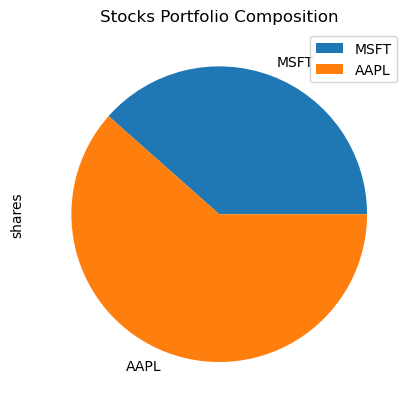

In [13]:
# Create a pie chart to show the proportion of stocks in the portfolio
df_shares.plot.pie(y="shares", title="Stocks Portfolio Composition")

<AxesSubplot: title={'center': 'Current Value in Dollars of Stock Portfolio'}>

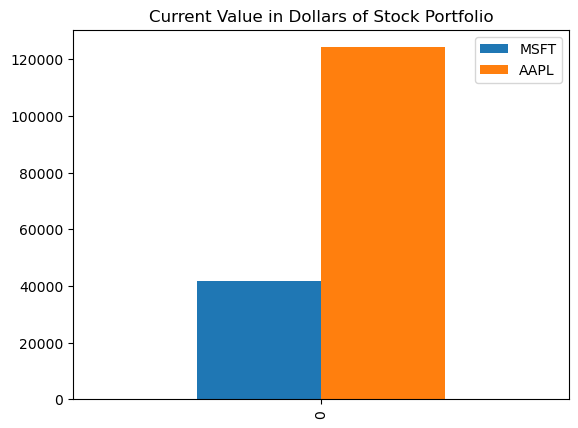

In [14]:
# Create a bar plot to show the value of shares
df_value.plot.bar(title="Current Value in Dollars of Stock Portfolio")